# Random action agent

In [1]:
import pprint
from Environment.simulator import *
from Environment.my_utils import *
from stable_baselines3.common.env_checker import check_env

import warnings
warnings.filterwarnings("ignore")

In [2]:
SLA = 3
VM_TYPE1 = 7
VM_TYPE2 = 3
VM_TYPE3 = 1
PENALTY = 200
STEPS = 100
ALPHA = 0.5
BETA = 0.5

Check if my custom enivorment correctly follow OpenAI Gym structure

In [3]:
# check_env(env, warn=0, skip_render_check=1)

In [4]:
def run_episode(print_info=False):
    
    env = Sim(sla = SLA,
          vm_1 = VM_TYPE1,
          vm_2 = VM_TYPE2,
          vm_3 = VM_TYPE3,
          steps = STEPS,
          penalty = PENALTY,
          scenario = 'train',
          alpha = ALPHA,
          beta = BETA)
    
    state = env.reset()
    done = False
    score = 0 
    while not done:
        action = env.action_space.sample()
        n_state, reward, done, info = env.step(action)
        
        if print_info:
            pp = pprint.PrettyPrinter(indent=5)
            print("Action: ", action)
            print("Reward: ", reward)
            print("Next state: ", n_state)
            pp.pprint(info)
            print("-----------------------------------------")
        
        score+=reward
    return score

Run single episode and look up detailed information step by step

In [5]:
# run_episode(print_info=True)

Vizualize performce on sample episode

In [6]:
def test_scenario(SCENARIO):
    env = Sim(sla = SLA,
              vm_1 = VM_TYPE1,
              vm_2 = VM_TYPE2,
              vm_3 = VM_TYPE3,
              steps = 100,
              penalty = PENALTY,
              scenario = SCENARIO,
              alpha = ALPHA,
              beta = BETA)

    obs = env.reset()
    culumative_reward = 0
    step = 0
    value = []
    quality_of_service = []
    utility_function = []
    no_of_vm_lst = []
    steps_lst = []
    queues = {}

    while True:
        action = env.action_space.sample()
        obs, rewards, done, info = env.step(action)

        # save the resuls
        culumative_reward+=rewards
        step +=1
        value.append(culumative_reward)
        steps_lst.append(step)
        quality_of_service.append(info['Quality of Service'])
        utility_function.append(obs)
        queues[step] = info['Semi-stochastic queue']
        no_of_vm_lst.append(info['VM type I'] + info['VM type II'] + info['VM type III'])

        if done: 
            print('info', info)
            break
    
    # average queue
    queue_df = pd.DataFrame(queues)
    queue_avg = list(queue_df.mean(axis=1))
    utility_function = list(np.reshape(utility_function, [STEPS,]))
    
    viz_performance(cumulative_reward=value,
                   utility_function=utility_function,
                   qos=quality_of_service,
                   no_of_vm = no_of_vm_lst,
                   steps=steps_lst,
                   sla=SLA,
                   queue_avg=queue_avg)
    
    print_stats(value, quality_of_service, utility_function, no_of_vm_lst)

In [7]:
#value, utility_function, quality_of_service, no_of_vm_lst, steps_lst, queue_avg = test_scenario(SCENARIO='test_scenario_1')

info {'Quality of Service': 2.629303589710928, 'Current cost': 375, 'Semi-stochastic queue': [3, 4, 5, 7, 7, 9, 9, 11, 11, 9], 'Timer': 3.803288459777832, 'VM type I': 6, 'VM type II': 3, 'VM type III': 2}


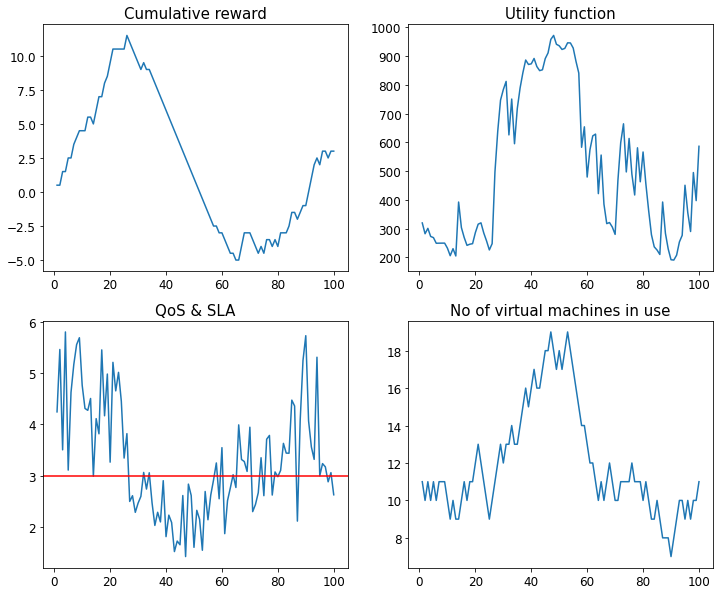

Cumulative reward at the end of the test:  3.0
Avg cost minus penalty per step:  507.04
Avg quality of service:  3.31
Avg no of virtual machines:  12.02


In [8]:
test_scenario(SCENARIO='test_scenario_1')

info {'Quality of Service': 3.141495306299058, 'Current cost': 325, 'Semi-stochastic queue': [8, 9, 7, 5, 3, 4, 5, 4, 9, 9], 'Timer': 3.183197498321533, 'VM type I': 5, 'VM type II': 0, 'VM type III': 3}


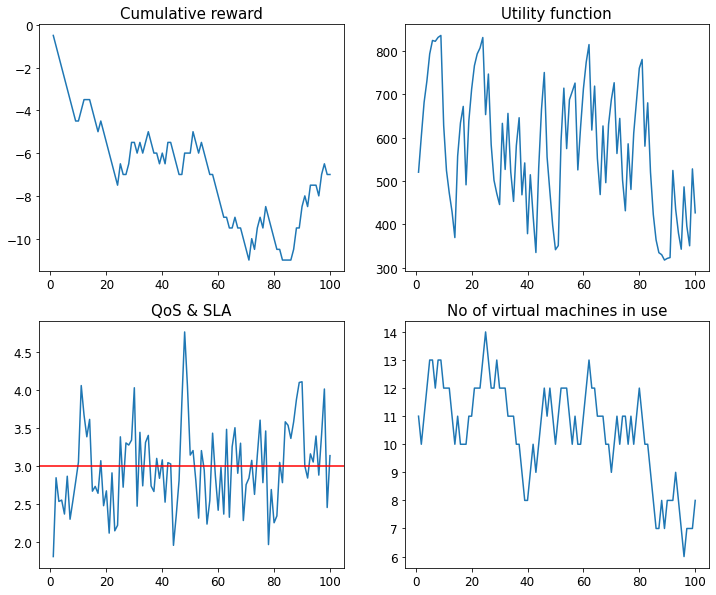

Cumulative reward at the end of the test:  -7.0
Avg cost minus penalty per step:  571.69
Avg quality of service:  2.99
Avg no of virtual machines:  10.48


In [9]:
test_scenario(SCENARIO='test_scenario_2')

info {'Quality of Service': 2.4692771247122405, 'Current cost': 420, 'Semi-stochastic queue': [9, 9, 9, 7, 7, 5, 4, 6, 3, 3], 'Timer': 4.0497682094573975, 'VM type I': 1, 'VM type II': 5, 'VM type III': 3}


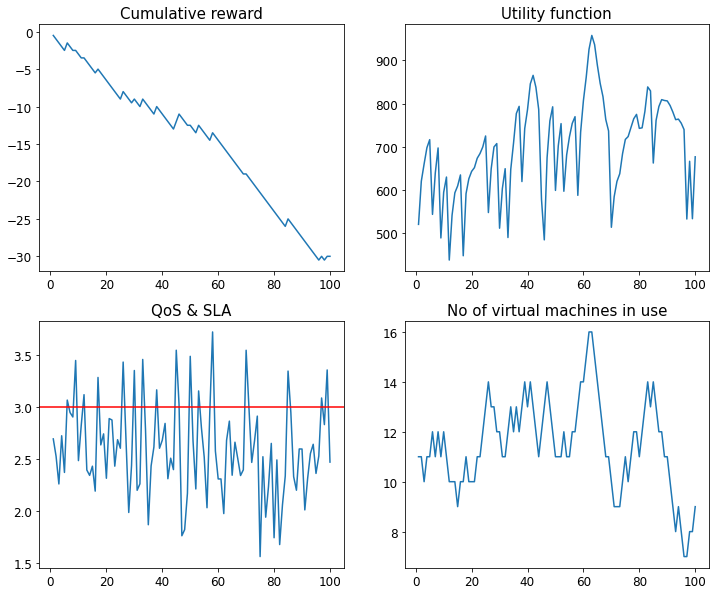

Cumulative reward at the end of the test:  -30.0
Avg cost minus penalty per step:  696.88
Avg quality of service:  2.6
Avg no of virtual machines:  11.49


In [10]:
test_scenario(SCENARIO='test_scenario_3')